##Часть 1 — Анализ FastQC

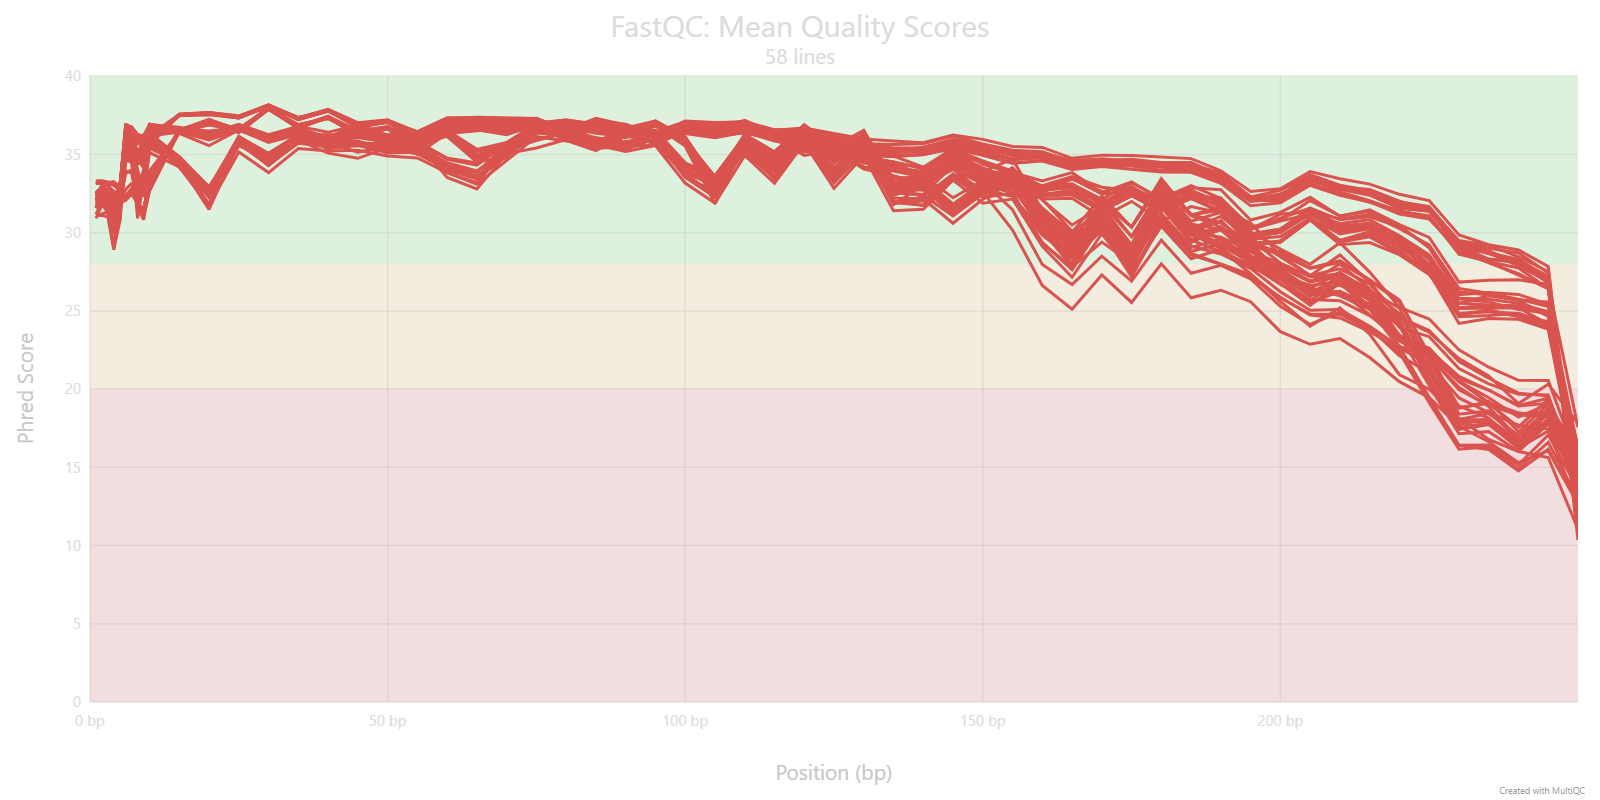

На графике Sequence Quality мы видим, что от начала прочтения до примерно 150-155 bp качество остаётся стабильно высоким. Начиная примерно со 155 bp. качество начинает снижаться, падая до красной зоны с высокой веротяностью ошибки

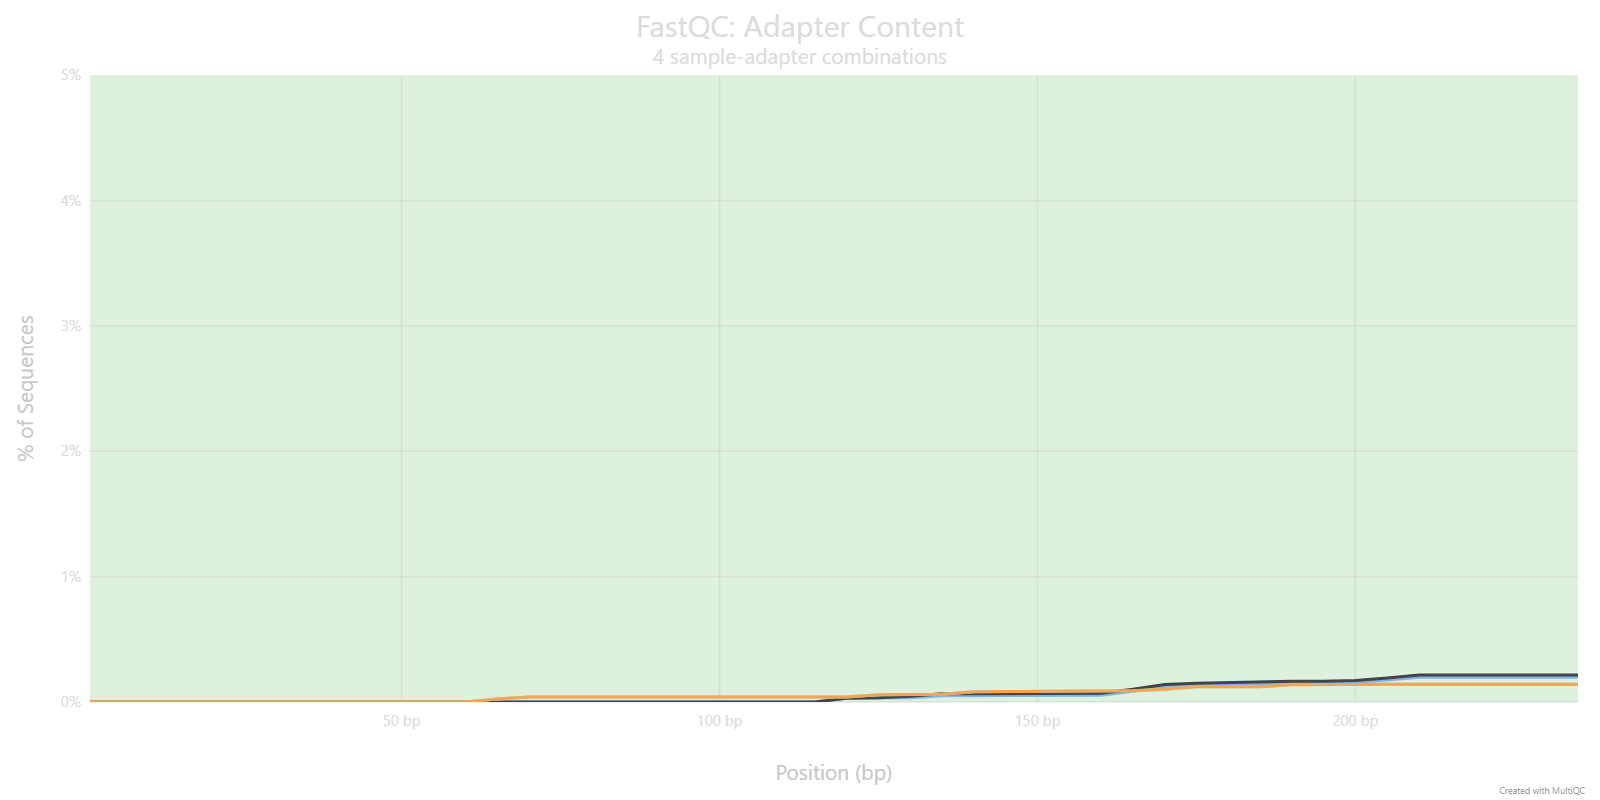

По графику содержания адаптерных последовательностей видно, что уровень контаминации по всем образцам остаётся низким на протяжении всей длины прочтения. Доля последовательностей с обнаруженным адаптером не превышает 0.3% даже к концу прочтения, тримминг не потребуется

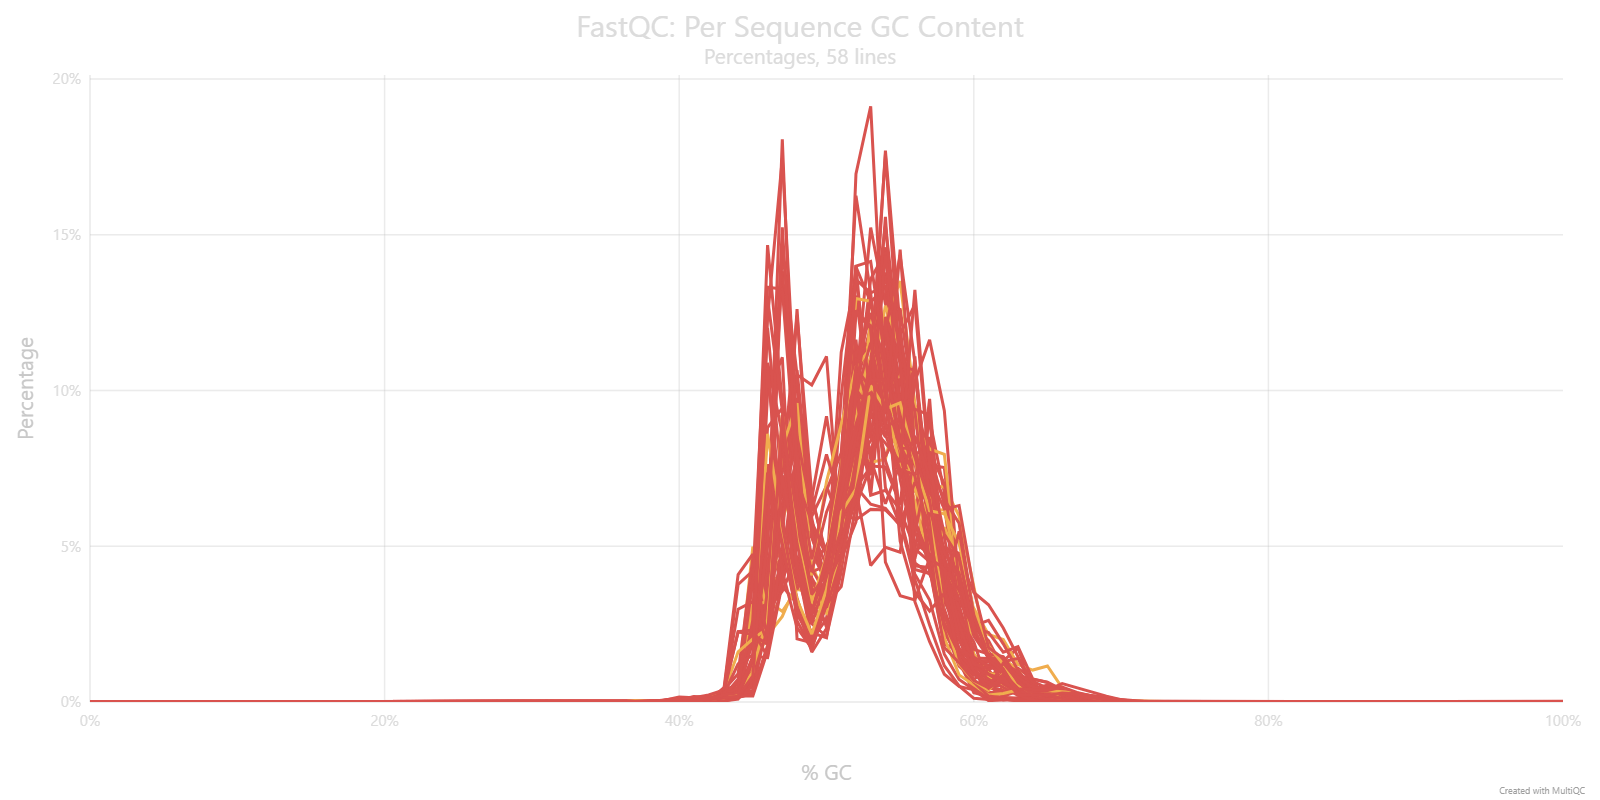

На графике процентного распределения GC ярко выражены 2 пика. Возможно это объясняетсяя тем, что в образце присутствует бактериальное сообщество, состоящее из множества таксонов с различным содержанием GC в их 16S rRNA генах. То есть присутствуют как минимум две крупные группы бактерий


##Часть 2 — QIIME 2

1) Загрузим данные в формате *qza для импорта внутрь системы QIIME2

MG=/home/STUDY/FBMF/studfbmf02_05/term_2/sem_1

In [ ]:
(base) [studfbmf02_05@calc ~]$ qiime tools import \
  --type 'SampleData[PairedEndSequencesWithQuality]' \   #указание типа импортируемых данных
  --input-path $MG/mice_manifest_clean.tsv \   #путь к таблице (файл metadata_for_input с убранными переносами строк), где прописано соответствие: sample-id - fastq файл
  --output-path $MG/qza/mice_reads.qza \   #путь для сохранения результата
  --input-format PairedEndFastqManifestPhred33V2  #указание формата данных manifest-файла

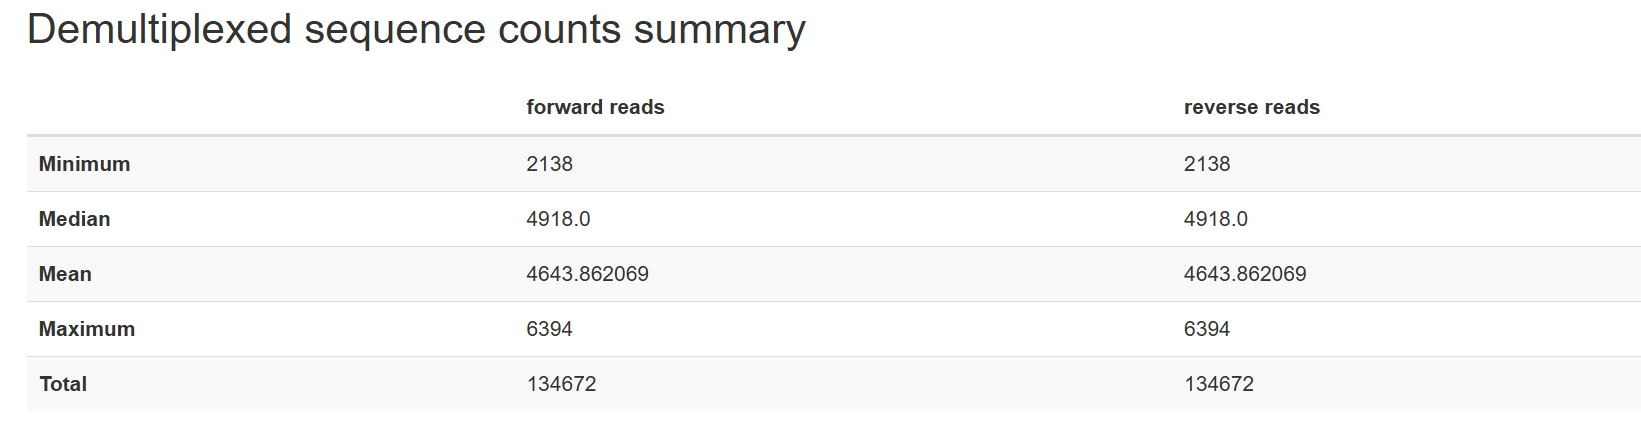

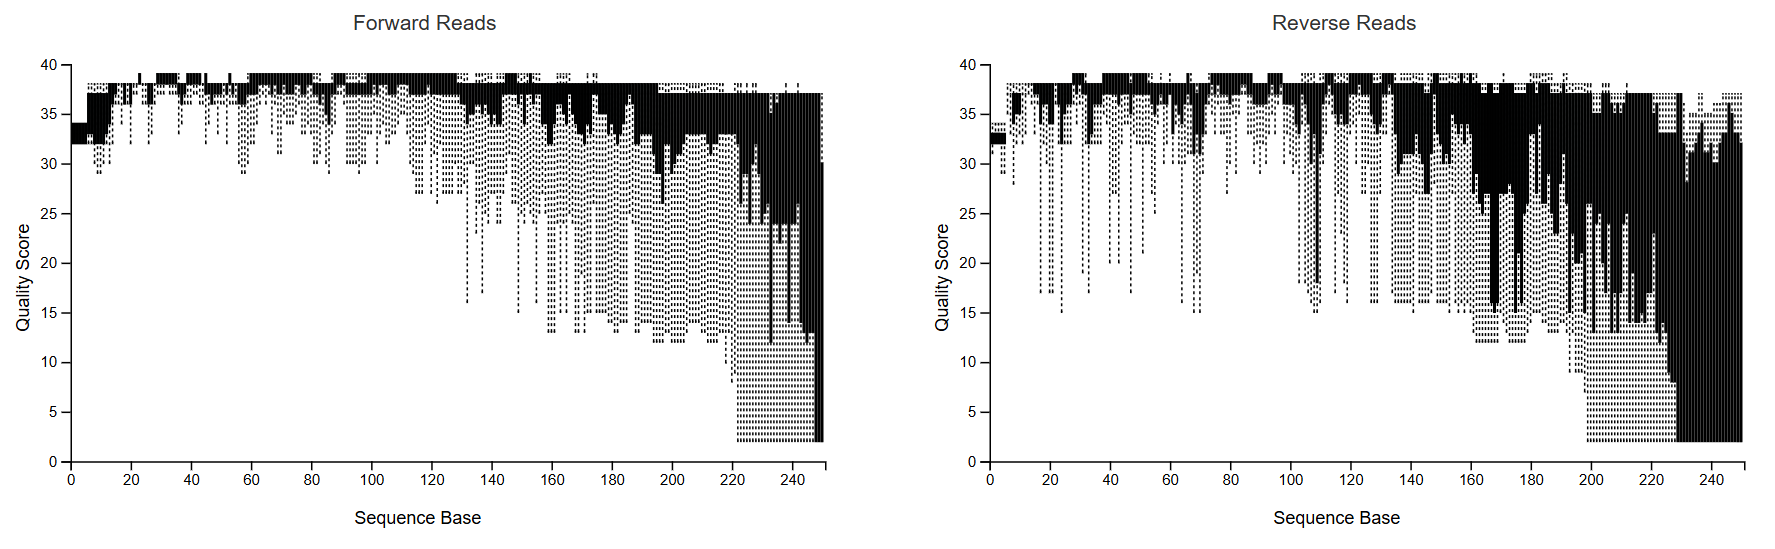

Interactive Quality Plot показывает, что что для forward-цепей качество высокое до позиции 180bp, после чего начинается снижение. Для reverse-цепей наблюдается схожая динамика в начале с локальным снижением качества в некоторых местах

2) Далее для предобработки данных написала SLURM-скрипт `run_dada2.sh`

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=dada2_mice
#SBATCH --cpus-per-task=4
#SBATCH --mem=16gb
#SBATCH --time=02:00:00
#SBATCH --output=logs/dada2_mice.%j.log
#SBATCH --partition=AMD9554-common

MG=/home/STUDY/FBMF/studfbmf02_05/term_2/sem_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime dada2 denoise-paired \
    --i-demultiplexed-seqs $MG/qza/mice_reads.qza \
    --p-trim-left-f 0 \
    --p-trim-left-r 0 \
    --p-trunc-len-f 180 \
    --p-trunc-len-r 150 \
    --p-n-threads 4 \
    --o-table $MG/qza/mice_ASV_table.qza \
    --o-representative-sequences $MG/qza/mice_rep_seq.qza \
    --o-denoising-stats $MG/qza/mice_reads.dada2.stats.qza

Посмотрим на статистику:

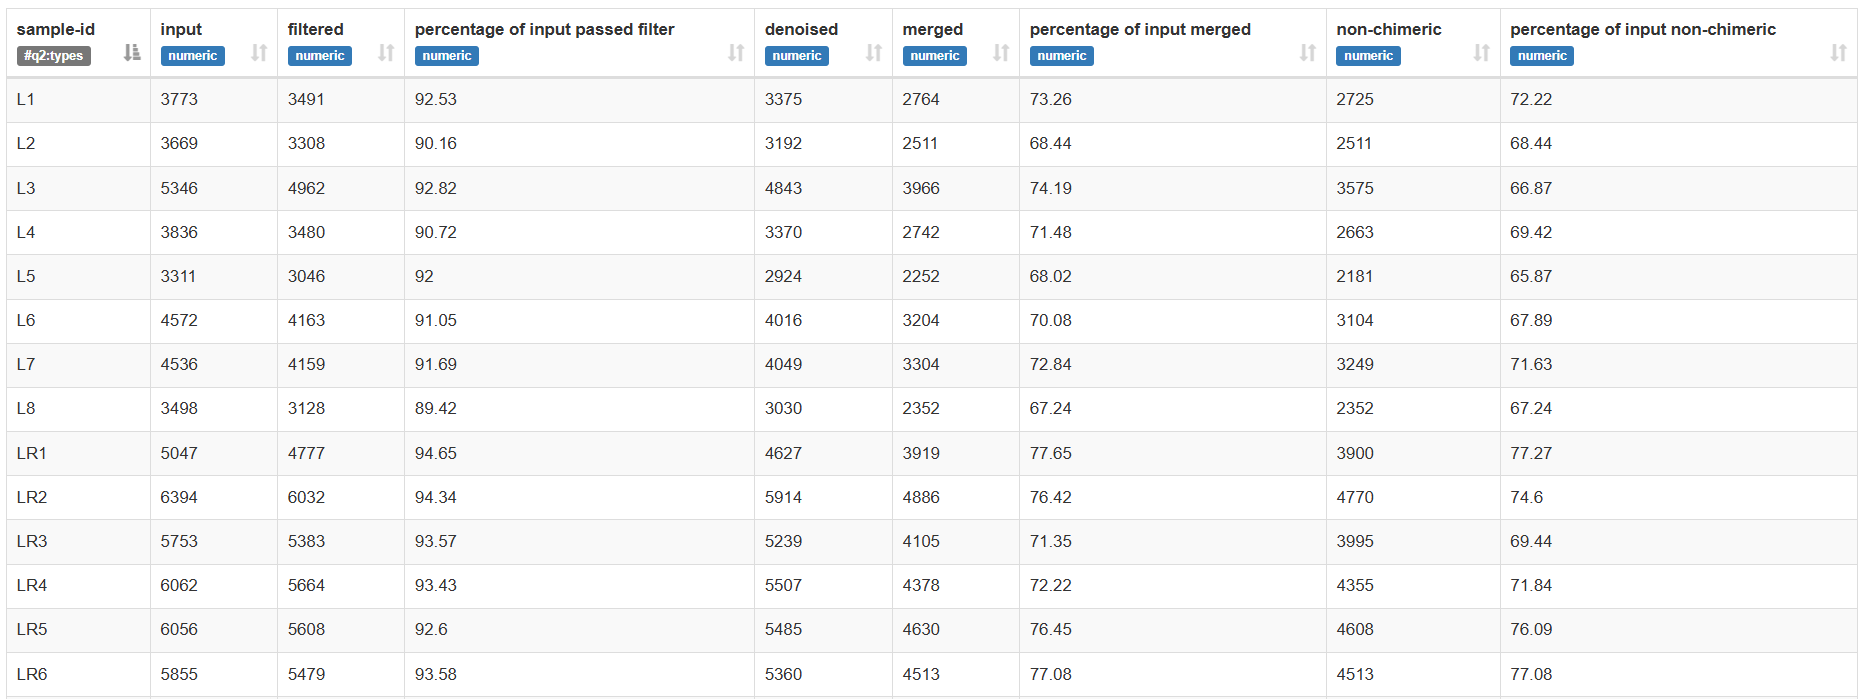

Видно, что после слияния ридов их число падает, это связано с тем что я обрезала reverse до 150, а forward до 180

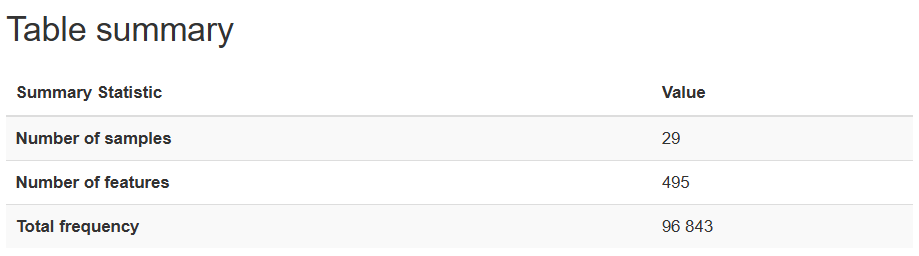

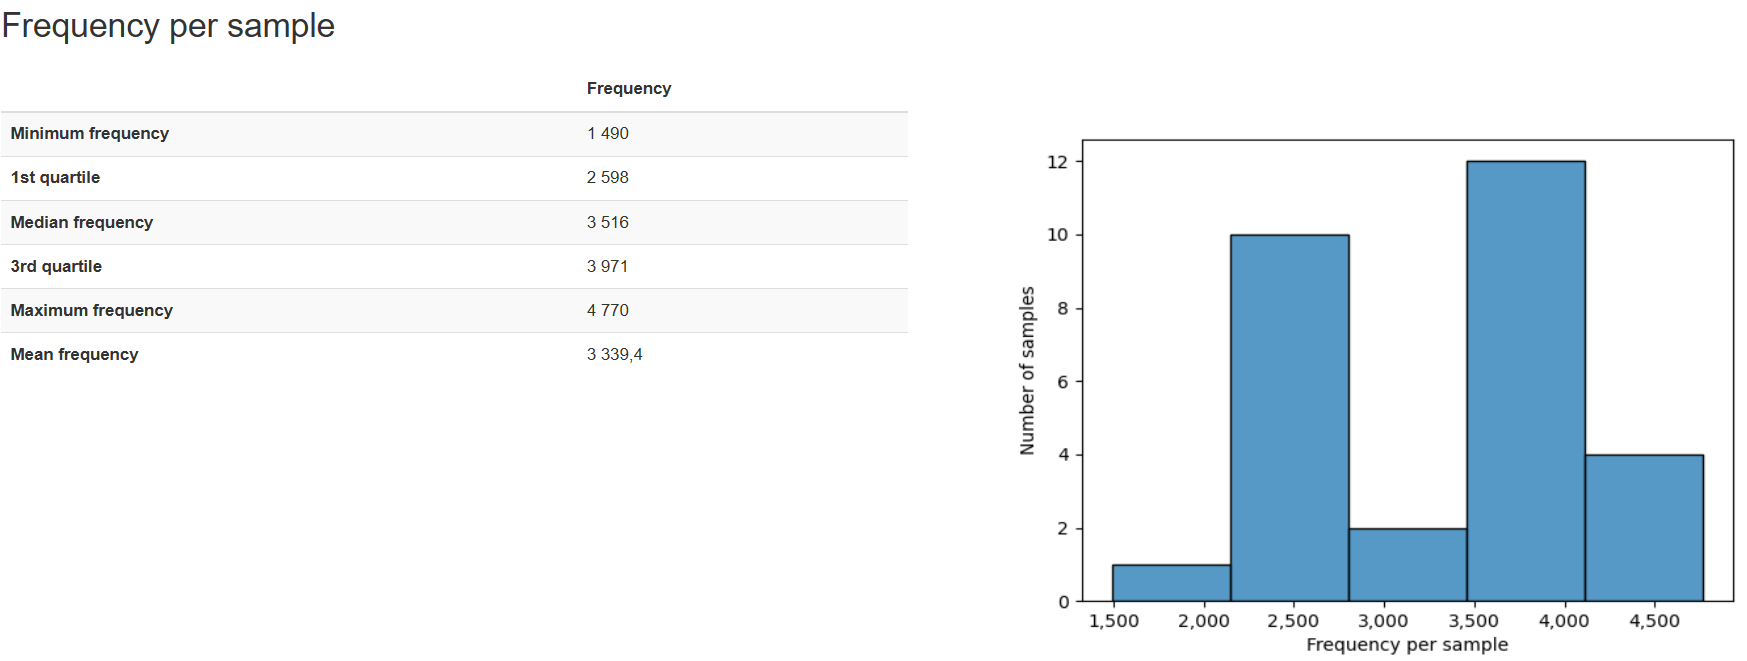

Получили 29 образцов и 495 уникальных ASV

3) Каждому из наших 495 ASV присвоим биологическое название, используя байесовский классификатор (запуск через SLURM) + сделаем доступным к просмотру через view.qiime2.org

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=classify_mice
#SBATCH --cpus-per-task=8
#SBATCH --mem=16gb
#SBATCH --time=02:00:00
#SBATCH --output=logs/classify_mice.%j.log
#SBATCH --partition=AMD9554-common

MG=/home/STUDY/FBMF/studfbmf02_05/term_2/sem_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime feature-classifier classify-sklearn \
    --i-classifier /home/STUDY/FBMF/bioinformatics/metagenomes/mice/2022.10.backbone.v4.nb.sklearn-1.4.2.qza \
    --p-n-jobs 8 \
    --i-reads $MG/qza/mice_rep_seq.qza \
    --o-classification $MG/qza/mice_taxonomy.qza

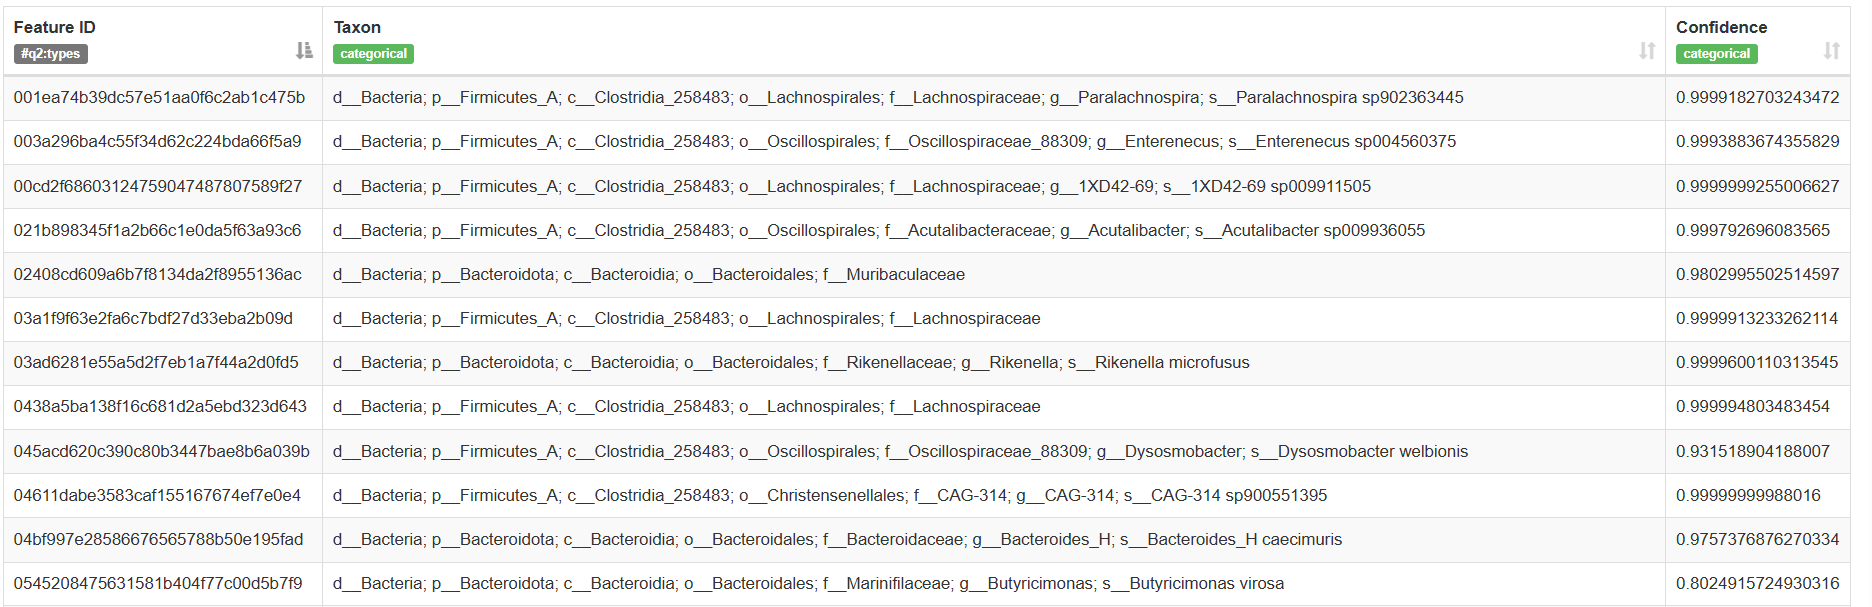

4) Визуализируем полученную таксономию и посмотрим состав на уровне типов и на уровне классов

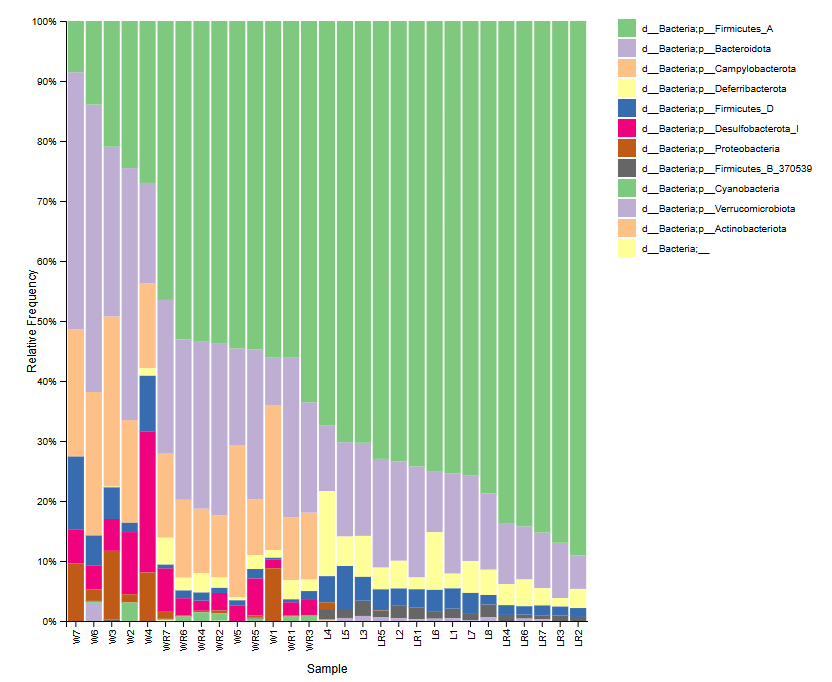

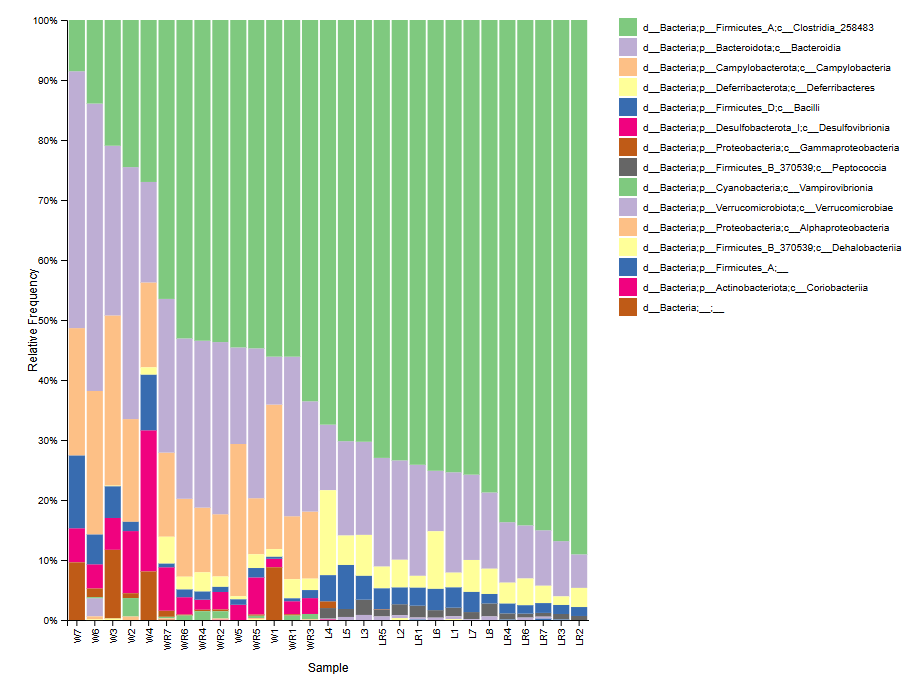

Этот график наглядно показывает, что состав микробиоты действительно систематически различается между дикими и лабораторными мышами (в левой части графика WT, а в правой части лабораторные с превалирующим % бактерий одного класса)

5) Построим филогенетическое дерево через SLURM-скрипт `run_tree.sh`

In [ ]:
# @title
#!/bin/sh
#SBATCH --job-name=tree_mice
#SBATCH --cpus-per-task=4
#SBATCH --mem=32gb
#SBATCH --time=02:00:00
#SBATCH --output=logs/tree_mice.%j.log
#SBATCH --partition=AMD9554-common

MG=/home/STUDY/FBMF/studfbmf02_05/term_2/sem_1

singularity exec \
  -H /home/STUDY/FBMF/studfbmf02_05/q2home:/home/qiime2 \
  -B /home/STUDY/FBMF \
  --env MPLCONFIGDIR=/home/STUDY/FBMF/studfbmf02_05/tmp,TMPDIR=/home/STUDY/FBMF/studfbmf02_05/tmp \
  ~/qiime2-amplicon-2024.10.sif qiime phylogeny align-to-tree-mafft-fasttree \
    --i-sequences $MG/qza/mice_rep_seq.qza \
    --o-alignment $MG/qza/aligned_mice_rep_seq.qza \
    --o-masked-alignment $MG/qza/masked_aligned_mice_rep_seq.qza \
    --o-tree $MG/qza/mice_unrooted_tree.qza \
    --o-rooted-tree $MG/qza/mice_rooted_tree.qza

На этапе визуализации у меня плагин qiime empress tree-plot оказался недоступен в используемом окружении, мне ИИ сказал можно попробовать использовать отдельно установленную версию Empress и получть html-визуализацию, но у меня он долго грузил(((  

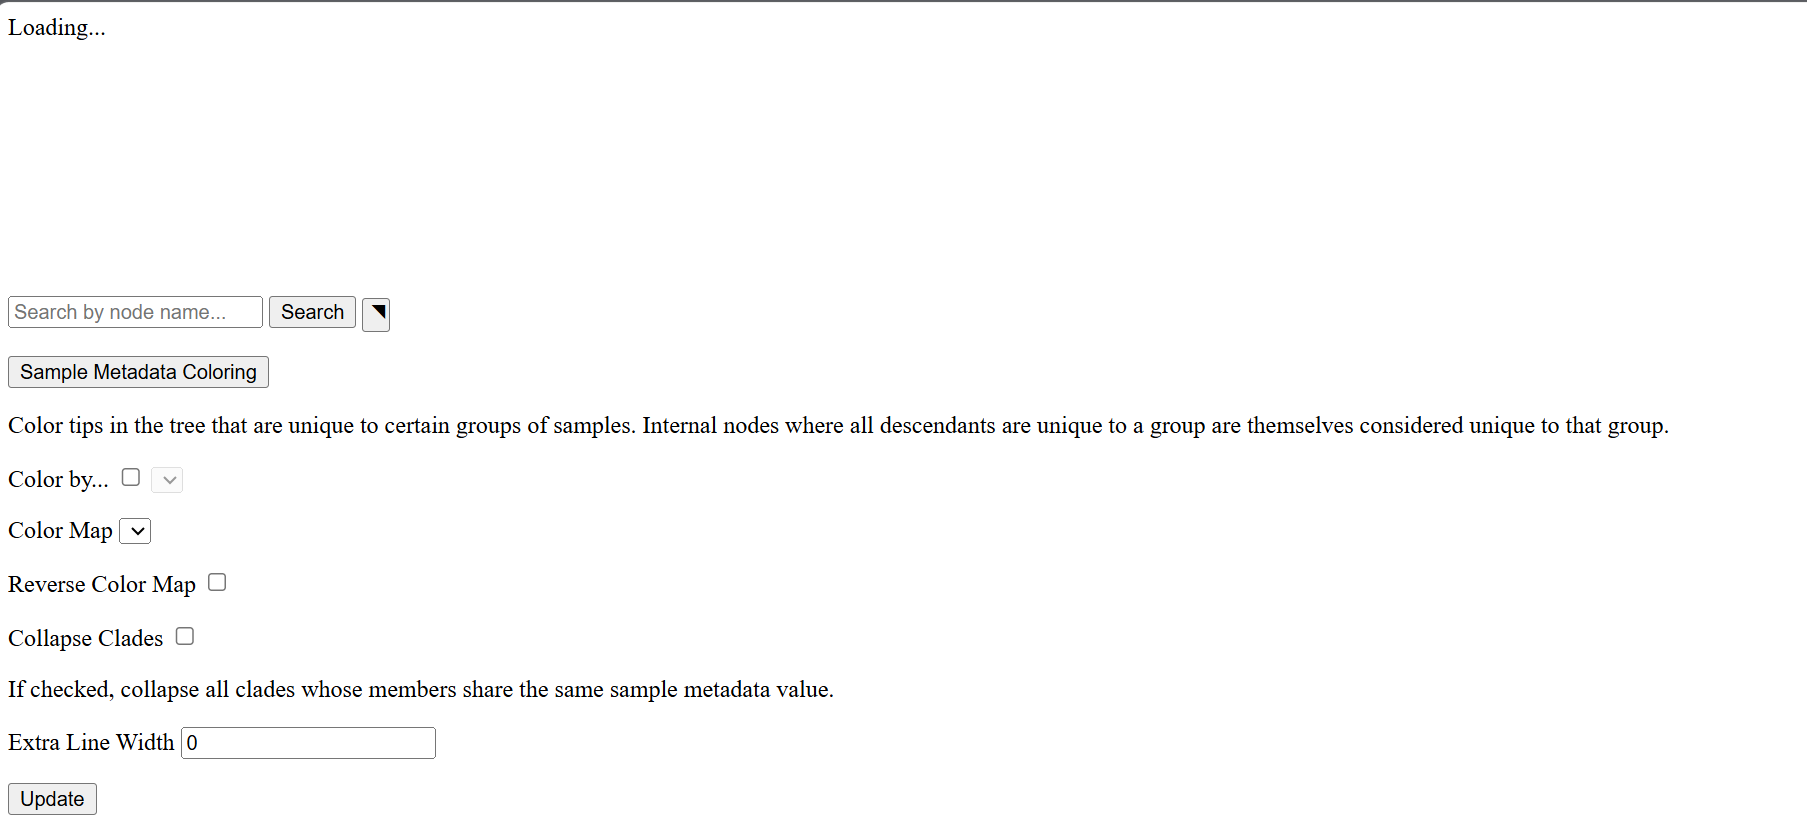

6) Посмотрим на статистику альфа и бета разнообразия

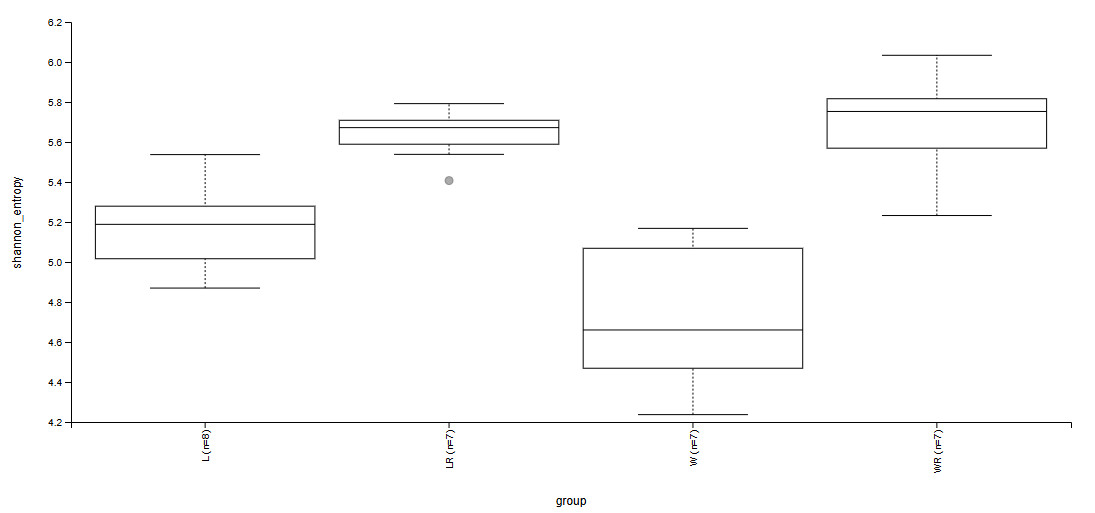

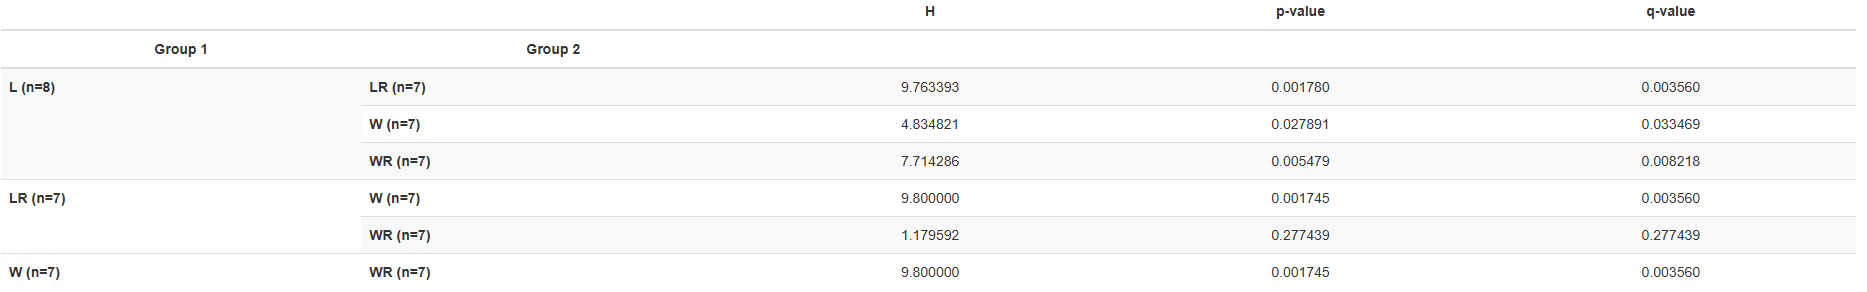

Наибольшее разнообразие наблюдается в группах WR и LR, но при попарных сравнениях они статистически незначимы.В остальных попарных сравнениях альфа-разнообразие действительно различается между большинством групп (5 из 6)

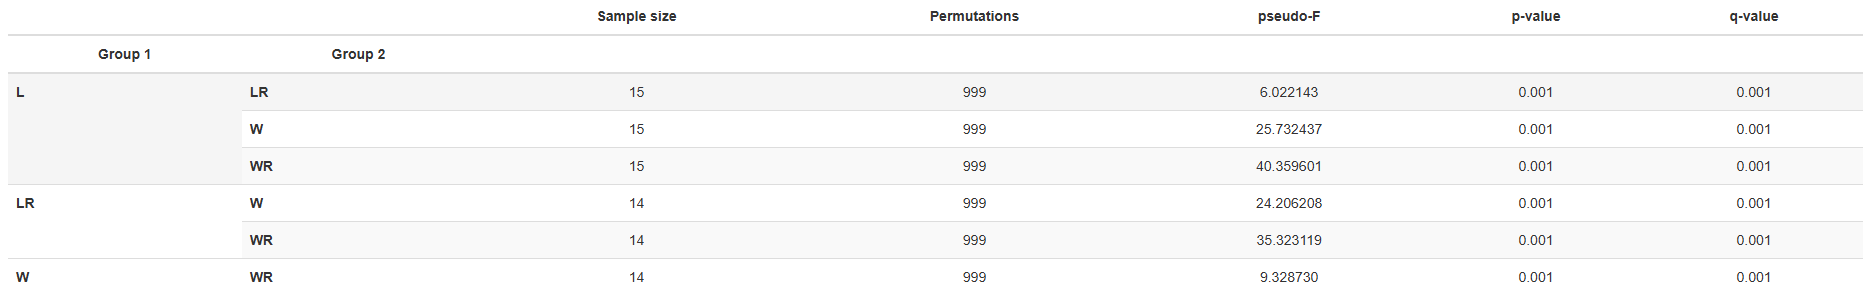

Бета-разнообразие оценивает, насколько различается таксономический состав микробиоты между разными образцами. В отличие от альфа-разнообразия, все 6 попарных сравнений оказались статистически значимыми, что указывает на выраженные различия в таксономическом составе микробиоты